# Autoencoders with TensorFlow

In this tutorial, we'll build an autoencoder that learns to reconstruct MNIST digits from a compressed representation. We'll first explore the basic encoder–bottleneck–decoder architecture, then extend it into a denoising autoencoder.

### Load the MNIST data

In [65]:
# Takes care of excessive tensorflow warnings
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

(x_train, _), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

Note 1: We do not need the lable data for the autoencoder, but it is intersting to observe the information the encoded data keeps in 2D, so we will keep the test lables for this visualization. 

Note 2: We flattened the 28x28 grayscale images to a vector of 728 already here. Alternatively we coluld also use a Flatten layer in the network, but this preprocessing is simple and does not need to put extra load on the network training. This also makes the dimensionality reduction more visible in the autoencoder structure.

In [67]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


### Build the autoencoder model

In [68]:
autoencoder = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),   # bottleneck
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(784, activation="sigmoid")
], name="autoencoder")

In [69]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Notice that the autoencoder consists of an encoder section and a decoder section.

The encoder compresses each 28×28 image (flattened to 784 pixels before being fed into the network) into a much smaller 32-dimensional representation:

**784 → 64 → 32**

The decoder then expands this representation back into a 784-pixel image:

**32 → 64 → 784**

The bottleneck forces the model to learn a compact representation of the information needed to reconstruct the original image.

In [70]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy()
)

### Why Binary Cross-Entropy?

Although we're not doing classification, binary cross-entropy works well here because our pixel values have been normalized to the range **0–1**.

The decoder's sigmoid output also produces values between **0 and 1**, allowing us to treat each pixel as a value whose target lies in this range.

The loss measures how closely the reconstructed pixels match the original pixels. For autoencoders, **mean squared error (MSE)** is another common choice, but BCE is a natural fit for normalized MNIST pixel values. 

```python
loss=keras.losses.MeanSquaredError()

## Train the model

In [71]:
%%time
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3617 - val_loss: 0.1729
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1647 - val_loss: 0.1422
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1384 - val_loss: 0.1246
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1239 - val_loss: 0.1171
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1178 - val_loss: 0.1135
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1139 - val_loss: 0.1091
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1097 - val_loss: 0.1056
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1065 - val_loss: 0.1033
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1041 - val_loss: 0.1015
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1028 - val_loss: 0.1000
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1007 - val_loss: 0.0986
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Why do we pass `x_train` to the fit method twice?

An autoencoder is trained to **reconstruct its input**, rather than predict a separate target such as a class label.

Therefore, the input and target are the same.

## Original vs Reconstructed images

In [73]:
def show_reconstructions(model, images, n=10):
    reconstructed = model.predict(images[:n], verbose=0) # pass the first n images through the autoencoder model

    fig, axes = plt.subplots(2, n, figsize=(15, 3))

    for i in range(n):
        axes[0, i].imshow(images[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

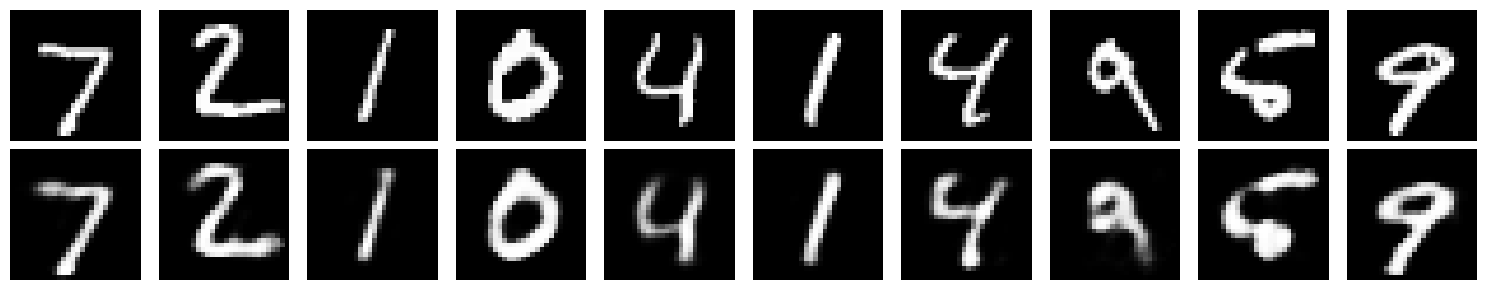

In [74]:
show_reconstructions(autoencoder, x_test)

# Encoder and decoder 

### Splitting the Autoencoder

We can use the trained layers to work with the encoder and decoder separately:

- **Encoder:** `784 → 64 → 32`
- **Decoder:** `32 → 64 → 784`

The decoder starts with a `Dense(64)` layer whose weights were learned from a **32-dimensional input**. Therefore, it can directly accept the 32-dimensional representations produced by the encoder.


In [75]:
encoder = keras.Sequential(autoencoder.layers[:2])
decoder = keras.Sequential(autoencoder.layers[2:])

In [76]:
encoded_images = encoder.predict(x_test, verbose=0) 

print(encoded_images.shape)

(10000, 32)


In [77]:
print(encoded_images[1])

[ 8.597039   5.415466   0.        30.975863  15.946531   8.881319
 11.589578   6.807235  10.682307  10.074173   8.546783   2.9146724
  6.317532  14.344276   7.776196   6.407302   0.6785276  0.
  8.956635   0.         4.358274   6.3485756  3.6912065  1.4798754
  9.221788   4.0735455 13.271243   7.6564255  9.203277   4.579361
  7.4756837  7.5195518]


In [78]:
original = x_test[0]
encoded = encoded_images[0]

print(f"Original image: {original.nbytes} bytes ({original.nbytes / 1024:.2f} KB)")
print(f"Encoded image:  {encoded.nbytes} bytes ({encoded.nbytes / 1024:.2f} KB)")
print(f"Compression ratio: {original.nbytes / encoded.nbytes:.1f}x")

Original image: 3136 bytes (3.06 KB)
Encoded image:  128 bytes (0.12 KB)
Compression ratio: 24.5x


### Exploring the Latent Space

We've seen that the encoder compresses each image into a **32-dimensional representation**. Let's play with these representations and see whether they contain any recognizable structure.

Since we can't visualize 32 dimensions directly, we'll use **PCA** to project the representations down to 2 dimensions.

The autoencoder was trained **without using the digit labels**, so the labels play no role in this experiment. We'll only use them to color the points afterwards and see whether different digits naturally occupy different regions of the latent space.

In other words, we're asking:

> **Does the unsupervised representation learned by the autoencoder capture information about digit identity?**



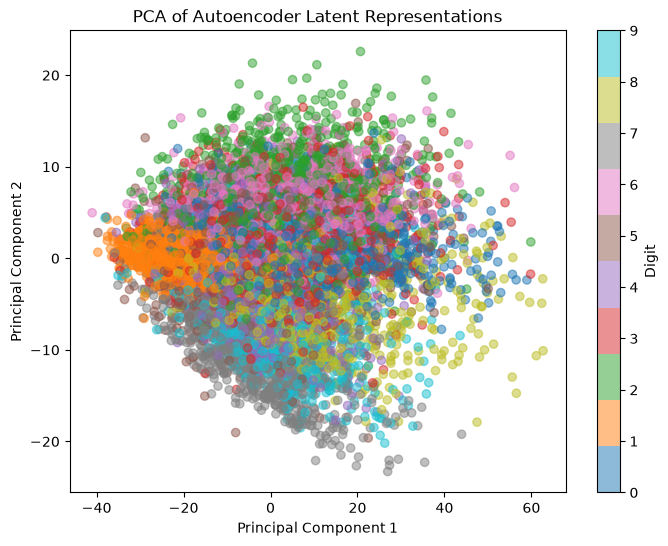

In [79]:
from sklearn.decomposition import PCA

encoded_2d = PCA(n_components=2).fit_transform(encoded_images)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    encoded_2d[:, 0],
    encoded_2d[:, 1],
    c=y_test,
    cmap="tab10",
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Autoencoder Latent Representations")
plt.colorbar(scatter, label="Digit")
plt.show()

Now let us decode the encoded representations back to images.

In [80]:
decoded_images = decoder.predict(encoded_images, verbose=0)
print(decoded_images.shape)

(10000, 784)


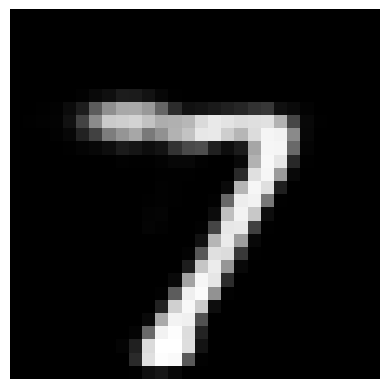

In [81]:
plt.imshow(decoded_images[0].reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()

## Denoising Autoencoder

So far, our autoencoder has learned to reconstruct an image from the image itself:

**clean image → encoder → bottleneck → decoder → reconstructed image**

We can make the task more interesting by adding noise to the input.

The model will now receive a **noisy image** but still be trained against the **original clean image**:

**noisy image → encoder → bottleneck → decoder → clean image**

This forces the autoencoder to learn useful structure in the digits rather than simply copying the input.

We'll add random noise to the training and test images, clip the resulting pixel values back to the **0–1** range, and train the same autoencoder to reconstruct the original images.


In [82]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

In [83]:
denoising_autoencoder = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(784, activation="sigmoid")
], name="denoising_autoencoder")

denoising_autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

### A Note on Keras Syntax

Notice that this time we used the shorter string-based syntax for common optimizers and losses that Keras also provides. We used the same optimizer and loss with the explicit syntax when compiling the first autoencoder.

For example, these are equivalent:

```python
# Explicit
optimizer=keras.optimizers.Adam()
loss=keras.losses.BinaryCrossentropy()

# Shorthand
optimizer="adam"
loss="binary_crossentropy"
````


In [84]:
denoising_autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
%%time
history = denoising_autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3536 - val_loss: 0.1998
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1928 - val_loss: 0.1713
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1696 - val_loss: 0.1599
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1587 - val_loss: 0.1511
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1506 - val_loss: 0.1457
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1460 - val_loss: 0.1420
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1424 - val_loss: 0.1387
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1392 - val_loss: 0.1363
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1369 - val_loss: 0.1346
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1353 - val_loss: 0.1332
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1336 - val_loss: 0.1319
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

## Denoising demo

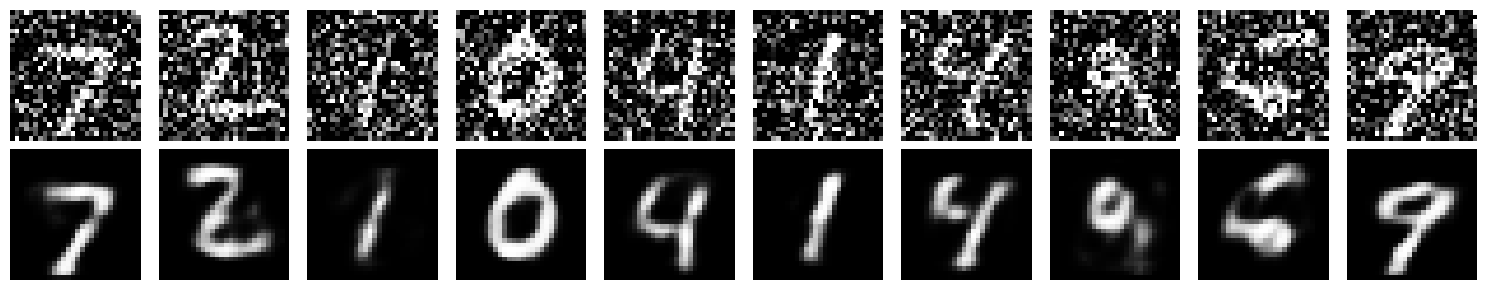

In [86]:
show_reconstructions(denoising_autoencoder, x_test_noisy)

### Where Does the Clean Training Data Come From?

A natural question is: **if our real images are noisy, where do we get the clean images needed as training targets?**

One possibility is to capture the **same scene multiple times**.

For example, suppose a camera takes several images of the same object in low-light conditions:

**same scene → noisy image 1**  
**same scene → noisy image 2**  
**same scene → noisy image 3**  
**...**

The underlying image is the same, but the noise is different in each capture.

If the noise is random and independent between images, combining many observations can provide a good approximation of the underlying clean image. That approximation can then be used as a training target.

There are also methods such as **Noise2Noise** that can learn from pairs of noisy images without ever requiring a perfectly clean target.

The important idea is that we need some source of information about the **underlying signal**. 

